# EMNIST — Inférence sur images custom

### Améliorations v2
- `kernel_size=3` partout (cohérent avec le modèle entraîné v2)
- Suppression de `preprocess_image_28x28` → une seule fonction universelle
- Lissage gaussien avant crop → robuste au bruit et artefacts
- Seuil de crop adaptatif (Otsu) pour mieux isoler le caractère
- `predict_from_image` retourne aussi un graphique Top-5

## 1. Chargement du modèle

In [1]:
import os
os.environ["KERAS_BACKEND"] = "torch"

import torch
import keras
import numpy as np
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image
from torchvision.transforms import v2
from torchvision.datasets import EMNIST
from scipy.ndimage import gaussian_filter

NUM_CLASSES = 62

# Architecture CNN — doit rester strictement identique au notebook d'entraînement v2
# pour que le chargement des poids (load_weights) soit compatible.

class EMNISTModel(keras.Model):
    def __init__(self, num_classes: int = NUM_CLASSES):
        super().__init__()

        # Bloc 1
        self.conv1    = keras.layers.Conv2D(32, kernel_size=3, padding="same", activation="relu")
        self.bn1      = keras.layers.BatchNormalization()
        self.sdrop1   = keras.layers.SpatialDropout2D(0.1)   # régularise les feature maps entières (mieux qu'un Dropout scalaire)
        self.pool1    = keras.layers.MaxPooling2D(2)          # 28 → 14

        # Bloc 2
        self.conv2    = keras.layers.Conv2D(64, kernel_size=3, padding="same", activation="relu")
        self.bn2      = keras.layers.BatchNormalization()
        self.sdrop2   = keras.layers.SpatialDropout2D(0.1)
        self.pool2    = keras.layers.MaxPooling2D(2)          # 14 → 7

        # Bloc 3
        self.conv3    = keras.layers.Conv2D(128, kernel_size=3, padding="same", activation="relu")
        self.bn3      = keras.layers.BatchNormalization()
        self.sdrop3   = keras.layers.SpatialDropout2D(0.1)

        # Bloc 4 — pas de MaxPool : la carte spatiale est déjà à 7×7 après pool2
        self.conv4    = keras.layers.Conv2D(256, kernel_size=3, padding="same", activation="relu")
        self.bn4      = keras.layers.BatchNormalization()

        self.gap      = keras.layers.GlobalAveragePooling2D()

        # Tête de classification : GAP → Dropout → Dense(128) → Dropout → logits
        self.dropout1 = keras.layers.Dropout(0.4)
        self.fc1      = keras.layers.Dense(128, activation="relu",
                            kernel_regularizer=keras.regularizers.L2(1e-4))  # L2 pour limiter l'overfitting sur la couche dense
        self.dropout2 = keras.layers.Dropout(0.3)
        self.fc2      = keras.layers.Dense(num_classes)

    def call(self, x, training=False):
        x = keras.ops.transpose(x, axes=(0, 2, 3, 1))

        x = self.sdrop1(self.pool1(self.bn1(self.conv1(x), training=training)), training=training)
        x = self.sdrop2(self.pool2(self.bn2(self.conv2(x), training=training)), training=training)
        x = self.sdrop3(self.bn3(self.conv3(x), training=training), training=training)
        x = self.bn4(self.conv4(x), training=training)

        x = self.gap(x)
        x = self.dropout1(x, training=training)
        x = self.fc1(x)
        x = self.dropout2(x, training=training)
        return self.fc2(x)

# ── Chargement des poids ───────────────────────────────────────────────────
def load_model(weights_path: str = "best_emnist_model.weights.h5") -> keras.Model:
    """
    Recrée l'architecture et charge les poids sauvegardés.
    Args:
        weights_path : chemin vers le fichier .weights.h5
    Returns:
        model prêt pour l'inférence
    """
    m = EMNISTModel()
    m(torch.zeros(1, 1, 28, 28))    # build
    m.load_weights(weights_path)
    m.trainable = False
    print(f"Modèle chargé depuis '{weights_path}'")
    return m


# ── Récupération des labels de classes ────────────────────────────────────
def load_classes() -> list:
    """Récupère la liste des 62 classes EMNIST byclass."""
    dataset = EMNIST(root="data", split="byclass", train=False, download=True)
    return dataset.classes


# Initialisation : charge le modèle et récupère les labels depuis le dataset de test
model   = load_model("best_emnist_model.weights.h5")
CLASSES = load_classes()
print(f"Device : {'cuda' if torch.cuda.is_available() else 'cpu'}")


Modèle chargé depuis 'best_emnist_model.weights.h5'
Device : cuda


## 2. Preprocessing

Une seule fonction universelle qui gère **n'importe quelle taille d'image**.

Pipeline :
1. Convertir en niveaux de gris
2. Inverser si fond blanc / trait noir (EMNIST attend : fond noir, trait blanc)
3. **Lissage gaussien** pour atténuer le bruit avant détection du contenu
4. **Crop serré** avec seuil adaptatif (8% du max) pour isoler le caractère
5. **Resize proportionnel** pour tenir dans 20×20 (ratio préservé)
6. **Centrer** sur canvas noir 28×28 avec marge de 4 px (reproduit le format EMNIST)
7. Normalisation avec la moyenne et l'écart-type du dataset EMNIST/MNIST


In [3]:
# Transformation identique à celle utilisée pendant l'entraînement (tran_test)
# Important : toute divergence ici dégraderait les performances en inférence
transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.1307], std=[0.3081])
])


def preprocess_image(path: str) -> torch.Tensor:
    """
    Charge une image de n'importe quelle taille et la convertit
    en tensor 28×28 normalisé, en préservant le ratio du caractère.

    Args:
        path : chemin vers l'image (.png, .jpg, etc.)
    Returns:
        tensor de shape (1, 1, 28, 28) prêt pour le modèle
    """
    img = Image.open(path).convert("L")
    arr = np.array(img, dtype=np.uint8)

    # --- 1. Inverser si fond blanc / trait noir ---
    if arr.mean() > 127:
        arr = 255 - arr

    # --- 2. Lissage gaussien pour robustesse au bruit ---
    # On lisse pour trouver le crop, mais on garde arr original pour le contenu
    arr_smooth = gaussian_filter(arr.astype(np.float32), sigma=1)

    # --- 3. Crop autour du caractère ---
    # Seuil adaptatif : 8% du max (robuste aux traits légers)
    threshold = max(20, arr_smooth.max() * 0.08)
    rows = np.any(arr_smooth > threshold, axis=1)
    cols = np.any(arr_smooth > threshold, axis=0)

    if rows.any() and cols.any():
        row_min, row_max = np.where(rows)[0][[0, -1]]
        col_min, col_max = np.where(cols)[0][[0, -1]]
        arr = arr[row_min:row_max+1, col_min:col_max+1]

    # --- 4. Resize proportionnel pour tenir dans 20×20 ---
    MARGIN = 4   # pixels de marge sur chaque côté
    h, w   = arr.shape
    ratio  = (28 - 2 * MARGIN) / max(h, w)
    new_h  = max(1, int(h * ratio))
    new_w  = max(1, int(w * ratio))

    img_resized = Image.fromarray(arr).resize((new_w, new_h), Image.LANCZOS)
    arr_resized = np.array(img_resized)

    # --- 5. Centrer sur canvas noir 28×28 ---
    canvas = np.zeros((28, 28), dtype=np.uint8)
    y_off  = (28 - new_h) // 2
    x_off  = (28 - new_w) // 2
    canvas[y_off:y_off+new_h, x_off:x_off+new_w] = arr_resized

    # --- 6. Normalisation ---
    tensor = transform(Image.fromarray(canvas))   # (1, 28, 28)
    return tensor.unsqueeze(0)                    # (1, 1, 28, 28)


## 3. Prédiction

In [4]:
def predict(tensor: torch.Tensor, top_k: int = 5) -> list[tuple[str, float]]:
    """
    Prédit le caractère à partir d'un tensor normalisé.

    Args:
        tensor : shape (1, 1, 28, 28), sorti de preprocess_image()
        top_k  : nombre de prédictions retournées
    Returns:
        liste de tuples (classe, confiance%) triée par confiance décroissante
    """
    device = next(model.parameters()).device
    tensor = tensor.to(device)

    with torch.no_grad():
        logits = model(tensor, training=False)
        probs  = F.softmax(logits, dim=1).cpu().squeeze()

    top_probs, top_idx = probs.topk(top_k)

    return [
        (CLASSES[i.item()], round(p.item() * 100, 2))
        for i, p in zip(top_idx, top_probs)
    ]


def predict_from_image(path: str, top_k: int = 5, show_plot: bool = True) -> list[tuple[str, float]]:
    """
    Pipeline complet : image (toute taille) → prédiction + graphique.

    Args:
        path      : chemin vers l'image
        top_k     : nombre de prédictions à afficher
        show_plot : afficher le graphique Top-K (défaut True)
    Returns:
        liste de tuples (classe, confiance%)
    """
    tensor  = preprocess_image(path)
    results = predict(tensor, top_k=top_k)

    print(f"Image : {path}")
    print(f"  → Prédit : '{results[0][0]}'  ({results[0][1]}%)")
    print(f"  → Top-{top_k} : {results}")

    if show_plot:
        # Récupérer le tableau brut pour affichage
        arr_raw = np.array(Image.open(path).convert("L"))
        arr_28  = tensor.squeeze().cpu().numpy()

        labels_bar = [f"'{c}'" for c, _ in results]
        probs_bar  = [p        for _, p in results]
        colors     = ["#2ecc71" if i == 0 else "#3498db" for i in range(top_k)]

        fig, axes = plt.subplots(1, 3, figsize=(12, 3.5),
                                 gridspec_kw={"width_ratios": [1, 1, 2]})

        # Image originale
        axes[0].imshow(arr_raw, cmap="gray")
        axes[0].set_title(f"Original\n{Image.open(path).size}")
        axes[0].axis("off")

        # Image preprocessée (entrée réelle du modèle)
        axes[1].imshow(arr_28, cmap="gray")
        axes[1].set_title("Entrée modèle\n(28×28 normalisé)")
        axes[1].axis("off")

        # Barres Top-K
        bars = axes[2].barh(labels_bar[::-1], probs_bar[::-1], color=colors[::-1])
        axes[2].set_xlim(0, 100)
        axes[2].set_xlabel("Confiance (%)")
        axes[2].set_title(f"Top-{top_k} prédictions")
        for bar, prob in zip(bars[::-1], probs_bar):
            axes[2].text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
                         f"{prob:.1f}%", va="center", fontsize=10)

        plt.suptitle(f"Prédit : '{results[0][0]}'  ({results[0][1]:.1f}%)",
                     fontsize=14, fontweight="bold")
        plt.tight_layout()
        plt.show()

    return results

## 4. Debug du preprocessing

In [5]:
def debug_preprocess(path: str):
    """
    Affiche les 4 étapes intermédiaires du preprocessing pour diagnostiquer
    un mauvais résultat : original → niveaux de gris → crop → canvas 28×28.
    """
    img = Image.open(path).convert("L")
    arr = np.array(img, dtype=np.uint8)

    # Inverser
    if arr.mean() > 127:
        arr = 255 - arr
    arr_inv = arr.copy()

    # Crop
    arr_smooth = gaussian_filter(arr.astype(np.float32), sigma=1)
    threshold  = max(20, arr_smooth.max() * 0.08)
    rows = np.any(arr_smooth > threshold, axis=1)
    cols = np.any(arr_smooth > threshold, axis=0)
    if rows.any() and cols.any():
        r0, r1 = np.where(rows)[0][[0, -1]]
        c0, c1 = np.where(cols)[0][[0, -1]]
        arr_crop = arr[r0:r1+1, c0:c1+1]
    else:
        arr_crop = arr

    # Canvas final
    tensor   = preprocess_image(path)
    arr_final = tensor.squeeze().cpu().numpy()

    fig, axes = plt.subplots(1, 4, figsize=(13, 3.5))
    axes[0].imshow(np.array(Image.open(path).convert("L")), cmap="gray")
    axes[0].set_title(f"Original\n{Image.open(path).size}")
    axes[1].imshow(arr_inv, cmap="gray")
    axes[1].set_title(f"Inversé\n(si fond blanc)")
    axes[2].imshow(arr_crop, cmap="gray")
    axes[2].set_title(f"Après crop\n{arr_crop.shape}")
    axes[3].imshow(arr_final, cmap="gray")
    axes[3].set_title("Entrée modèle\n28×28")
    for ax in axes:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

## 5. Utilisation

Image : myletter/t.png
  → Prédit : 'a'  (15.17%)
  → Top-5 : [('a', 15.17), ('2', 8.86), ('O', 7.43), ('d', 6.13), ('g', 5.73)]


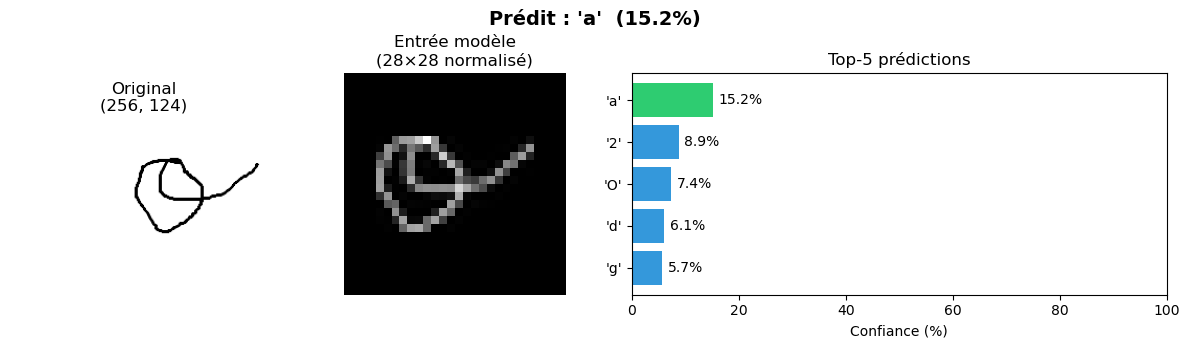

[('a', 15.17), ('2', 8.86), ('O', 7.43), ('d', 6.13), ('g', 5.73)]

In [15]:
# --- Prédiction simple avec graphique ---
predict_from_image("myletter/t.png")

# --- Sans graphique (juste le résultat) ---
# results = predict_from_image("mon_image.png", show_plot=False)

# --- Récupérer uniquement la meilleure prédiction ---
# best_class, confidence = predict_from_image("mon_image.png", show_plot=False)[0]
# print(f"Caractère : {best_class}, confiance : {confidence}%")

# --- Diagnostiquer le preprocessing si le résultat est mauvais ---
# debug_preprocess("mon_image.png")

# --- Tester plusieurs images d'un dossier ---
# from pathlib import Path
# for img_path in Path("mes_images").glob("*.png"):
#     predict_from_image(str(img_path))
#     print()